---
title: "Practice Activity 7-1: Association Rules"
author: "Shiqi Wu"
format:
  html:
    embed-resources: true
    code-overflow: wrap
---

## Practice Activity 7-1: Association Rules

In the reading you analyzed transactions from a bakery. In this activity you will carry out a very similar analysis for purchases from a grocery store.

In [1]:
import pandas as pd

from plotnine import *

from mlxtend.frequent_patterns import apriori, association_rules

# to stop an annoying warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

## Groceries data set

- One month (30 days) of real point-of-sale transactions from a grocery store.
- 9,835 transactions (baskets).
- 169 product categories, such as whole milk, yogurt, bottled beer, etc.
- Source: the data set `Groceries` in the R package `arules`, provided by Hahsler, Hornik, and Reutterer. The copy we use is a plain-text version hosted on GitHub.


The file format is different from the bakery file. The bakery file had one row per item bought. This file has **one line per transaction**, and each line is a comma-separated list of the items in that basket. Different baskets have different numbers of items.

The next cell reads each line into a single text column. (Normal CSV reading expects every row to have the same number of columns, so we read each line as one string, using a separator `"|"` that never occurs in the file.)

In [2]:
import csv

raw = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv",
    header=None,             # the file has no header row: line 1 is already a transaction
    names=["basket"],        # name the one column we create
    sep="|",                 # "|" never appears in this file, so each whole line lands in one column
    quoting=csv.QUOTE_NONE,  # treat any quote characters as ordinary text
)

In [3]:
raw

,basket
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."
...,...
9830,"sausage,chicken,beef,hamburger meat,citrus fru..."
9831,cooking chocolate
9832,"chicken,citrus fruit,other vegetables,butter,y..."
9833,"semi-finished bread,bottled water,soda,bottled..."


We'll start with the data in long format like in the reading.

- Make a column `basket_id` from the row number (`raw.index`).
- Split the text in `raw["basket"]` at the commas, using `.str.split(",")`. This produces a *list* of items in each row.
- Use `.explode(...)` on the column of lists to get one row per item.
- Keep only `basket_id` and `item`, and use `.reset_index(drop=True)`.
- Trim spaces

In [4]:
long = (
    raw
    .assign(basket_id=raw.index)                    # use the row number as the basket ID
    .assign(item=raw["basket"].str.split(","))      # "milk,bread" becomes ["milk", "bread"]
    .explode("item")                                # one row per (basket, item)
    [["basket_id", "item"]]                         # keep only the two columns we need
    .reset_index(drop=True)                         # renumber the rows 0, 1, 2, ...
)

long["item"] = long["item"].str.strip()             # remove stray leading/trailing spaces

long

,basket_id,item
0,0,citrus fruit
1,0,semi-finished bread
2,0,margarine
3,0,ready soups
4,1,tropical fruit
...,...,...
43362,9834,chicken
43363,9834,tropical fruit
43364,9834,other vegetables
43365,9834,vinegar


1. Build the transaction-by-item table `basket`. There should be one row per basket, one column per item, with `True` if the item is in the basket and `False` otherwise.

In [6]:
basket = pd.crosstab(long["basket_id"], long["item"]) > 0

print(basket.shape)
basket

(9835, 169)


item,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
basket_id,,,,,,,,,,,,,,,,,,,,,
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9830,False,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,True,False,False
9831,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9832,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


2.  Compute the size (number of items) of each basket and store it in `basket_sizes`.

In [7]:
basket_sizes = basket.sum(axis=1)

basket_sizes

basket_id
0        4
1        3
2        1
3        4
4        4
        ..
9830    17
9831     1
9832    10
9833     4
9834     5
Length: 9835, dtype: int64

3. Summarize the distribution of the number of items.

In [8]:
basket_sizes.value_counts().sort_index()

1     2159
2     1643
3     1299
4     1005
5      855
6      645
7      545
8      438
9      350
10     246
11     182
12     117
13      78
14      77
15      55
16      46
17      29
18      14
19      14
20       9
21      11
22       4
23       6
24       1
26       1
27       1
28       1
29       3
32       1
Name: count, dtype: int64

4. Compute the support of every item, sorted from largest to smallest, and store it in `item_support`. Then make a horizontal bar chart of the 15 most popular items.

item
whole milk          0.255516
other vegetables    0.193493
rolls/buns          0.183935
soda                0.174377
yogurt              0.139502
bottled water       0.110524
root vegetables     0.108998
tropical fruit      0.104931
shopping bags       0.098526
sausage             0.093950
pastry              0.088968
citrus fruit        0.082766
bottled beer        0.080529
newspapers          0.079817
canned beer         0.077682
dtype: float64


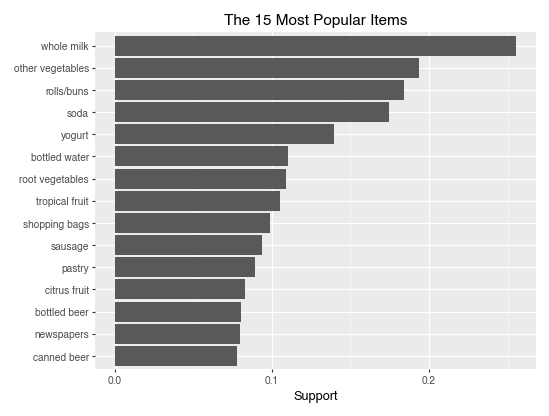

In [9]:
item_support = basket.mean().sort_values(ascending=False)

top15 = item_support.head(15).rename("support").reset_index()
top15["item"] = pd.Categorical(top15["item"], categories=top15["item"][::-1])

print(item_support.head(15))

(ggplot(top15, aes(x="item", y="support"))
 + geom_col()
 + coord_flip()
 + labs(x="", y="Support", title="The 15 Most Popular Items"))

5. Consider the basket sizes and the item supports. Which item is most popular, and in what percentage of baskets does it appear? Which items are most common? What does this suggest about the "popular items co-occur just by chance" problem discussed in the reading?

Answer: Whole milk is the most popular item, appearing in about 25.55% of baskets. Other common items include other vegetables, rolls/buns, soda, and yogurt. About 52% of baskets contain only one to three items. Since these products are common, they may appear together simply because of their popularity, rather than a strong association. We should examine lift alongside support and confidence to see whether they occur together more often than expected under independence.

6. Consider the rule **{yogurt} → {whole milk}**. Compute and interpret the confidence of this rule.


In [10]:
yogurt_support = basket["yogurt"].mean()
yogurt_milk_support = (basket["yogurt"] & basket["whole milk"]).mean()
yogurt_to_milk_confidence = yogurt_milk_support / yogurt_support

yogurt_to_milk_confidence

np.float64(0.40160349854227406)

Answer: The confidence of {yogurt} → {whole milk} is about 40.16%. This means that among baskets containing yogurt, about 40.16% also contain whole milk.

7. Compute and interpret the **lift** of {yogurt} → {whole milk}.

In [11]:
milk_support = basket["whole milk"].mean()
yogurt_to_milk_lift = yogurt_to_milk_confidence / milk_support

yogurt_to_milk_lift

np.float64(1.5717351405345266)

Answer: The lift of {yogurt} → {whole milk} is about 1.57. Whole milk appears in about 40.16% of baskets containing yogurt, compared with 25.55% of all baskets. It is therefore about 1.57 times as common in baskets containing yogurt, indicating a positive association, not causation.

8. Now compute and interpret the confidence and lift for the rule {whole milk} → {yogurt}.

In [12]:
milk_to_yogurt_confidence = yogurt_milk_support / milk_support
milk_to_yogurt_lift = milk_to_yogurt_confidence / yogurt_support

print(milk_to_yogurt_confidence)
print(milk_to_yogurt_lift)

0.21925984878631116
1.5717351405345263


Answer: The confidence of 'whole milk' → 'yogurt' is about 21.93%, meaning that 21.93% of baskets containing whole milk also contain yogurt. The lift is about 1.57, so yogurt is about 1.57 times as common in baskets containing whole milk as it is in all baskets. The reverse rule has lower confidence because whole milk is more common than yogurt, but the lift is the same in both directions.

9. Write two functions.

- `support(items, onehot)`: returns the share of baskets that contain **all** of the items in the list `items`.
- `rule_metrics(antecedent, consequent, onehot)`: returns a Pandas Series with the `support`, `confidence`, and `lift` of the rule `antecedent -> consequent`. Both `antecedent` and `consequent` are *lists* of items.

Test the functions on `["yogurt"]` → `["whole milk"]`. The values should match the ones you computed earlier.

In [13]:
def support(items, onehot):
    """Return the share of baskets containing all listed items."""
    return onehot[items].all(axis=1).mean()


def rule_metrics(antecedent, consequent, onehot):
    """Return the support, confidence, and lift of a rule."""
    s_a = support(antecedent, onehot)
    s_c = support(consequent, onehot)
    s_ac = support(antecedent + consequent, onehot)

    return pd.Series({
        "support": s_ac,
        "confidence": s_ac / s_a,
        "lift": s_ac / (s_a * s_c)
    })


rule_metrics(["yogurt"], ["whole milk"], basket)

support       0.056024
confidence    0.401603
lift          1.571735
dtype: float64

10. Whole milk is in about a quarter of all baskets. Consider the rules `{X} → {whole milk}` for the five antecedents `X` in the next cell. Before running anything, predict: for which of these will the lift be **above 1**? For which might the confidence look decent but the lift be **close to or below 1**? Just think about this before proceeding.

In [5]:
antecedents = pd.Series(["yogurt", "rolls/buns", "bottled water", "soda", "other vegetables"])

Answer: I expect yogurt, rolls/buns, and other vegetables to have lift above 1 for whole milk. Bottled water and soda may have lift close to or below 1. Their confidence could still look reasonable because whole milk already appears in about 25.55% of all baskets.

11. Compute the support, confidence, and lift of `{X} → {whole milk}` for each of the five antecedents above, and display the results sorted by lift (largest first). Compare to your predictions. Hint: Use `apply` with `lambda` on the Series of antecedents.


In [14]:
milk_rules = antecedents.apply(lambda x: rule_metrics([x], ["whole milk"], basket))
milk_rules.index = antecedents

milk_rules.sort_values("lift", ascending=False)

,support,confidence,lift
yogurt,0.056024,0.401603,1.571735
other vegetables,0.074835,0.386758,1.513634
bottled water,0.034367,0.310948,1.216940
rolls/buns,0.056634,0.307905,1.205032
soda,0.040061,0.229738,0.899112


Answer: Yogurt, other vegetables, and rolls/buns have lift above 1, as I predicted. Bottled water also has lift above 1, at about 1.22, which differs from my prediction. Soda has lift below 1, at about 0.90. Although its confidence is about 22.97%, this is lower than whole milk's overall support of 25.55%. This shows why confidence alone can be misleading.

12. Run `apriori` on `basket` with `min_support=0.01` and store the result in `frequent_itemsets`. Then add a column `n_items` giving the number of items in each itemset.

In [15]:
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
frequent_itemsets["n_items"] = frequent_itemsets["itemsets"].apply(len)

frequent_itemsets

,support,itemsets,n_items
0,0.033452,frozenset({UHT-milk}),1
1,0.017692,frozenset({baking powder}),1
2,0.052466,frozenset({beef}),1
3,0.033249,frozenset({berries}),1
4,0.026029,frozenset({beverages}),1
...,...,...,...
328,0.011998,"frozenset({root vegetables, tropical fruit, wh...",3
329,0.014540,"frozenset({root vegetables, yogurt, whole milk})",3
330,0.010473,"frozenset({yogurt, soda, whole milk})",3
331,0.015150,"frozenset({yogurt, tropical fruit, whole milk})",3


13. Generate the rules with `make_rules`, keeping rules with confidence of at least 0.20. Store them in `rules` and print how many there are.

In [16]:
def make_rules(frequent_itemsets, min_confidence):
    return association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)


rules = make_rules(frequent_itemsets, 0.20)

print(len(rules))

234


14. Make the rules easier to read. Create a copy `rules_display` of `rules` and add three columns:

- `antecedent`: the antecedent items as text, e.g. `"tropical fruit, yogurt"`
- `consequent`: the consequent items as text
- `transactions`: the number of baskets that contain the whole rule (support times the number of baskets, rounded to an integer)

Then display the columns `antecedent`, `consequent`, `support`, `confidence`, `lift`, `transactions` for the first 8 rules.

In [17]:
rules_display = rules.copy()
rules_display["antecedent"] = rules_display["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules_display["consequent"] = rules_display["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules_display["transactions"] = (rules_display["support"] * len(basket)).round().astype(int)

rules_display[["antecedent", "consequent", "support", "confidence", "lift", "transactions"]].head(8)

,antecedent,consequent,support,confidence,lift,transactions
0,beef,other vegetables,0.019725,0.375969,1.943066,194
1,beef,rolls/buns,0.013625,0.259690,1.411858,134
2,beef,root vegetables,0.017387,0.331395,3.040367,171
3,beef,whole milk,0.021251,0.405039,1.585180,209
4,beef,yogurt,0.011693,0.222868,1.597601,115
5,berries,other vegetables,0.010269,0.308869,1.596280,101
6,berries,whole milk,0.011795,0.354740,1.388328,116
7,berries,yogurt,0.010574,0.318043,2.279848,104


15. Show the 10 rules with the highest **confidence**. What do the highest-confidence rules have in common? Why is confidence alone a poor guide here?

In [18]:
show = ["antecedent", "consequent", "support", "confidence", "lift", "transactions"]

rules_display.sort_values("confidence", ascending=False)[show].head(10)

,antecedent,consequent,support,confidence,lift,transactions
157,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608,102
184,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999,121
163,"curd, yogurt",whole milk,0.010066,0.582353,2.279125,99
153,"butter, other vegetables",whole milk,0.011490,0.573604,2.244885,113
221,"root vegetables, tropical fruit",whole milk,0.011998,0.570048,2.230969,118
224,"root vegetables, yogurt",whole milk,0.014540,0.562992,2.203354,143
165,"domestic eggs, other vegetables",whole milk,0.012303,0.552511,2.162336,121
232,"whipped/sour cream, yogurt",whole milk,0.010880,0.524510,2.052747,107
213,"rolls/buns, root vegetables",whole milk,0.012710,0.523013,2.046888,125
171,"other vegetables, pip fruit",whole milk,0.013523,0.517510,2.025351,133


Answer: Eight of the ten highest-confidence rules predict whole milk, while the other two predict other vegetables. Both are popular items, and all ten rules have two-item antecedents. Confidence alone can be misleading because it does not account for how common the consequent is overall or how many baskets support the rule. These rules also have lift above 2, so their associations are not explained by popularity alone. We should compare confidence, lift, and support together.

16. Show the 10 rules with the highest **lift**. Compare this list with the highest-confidence list. What kinds of products appear now? Look at the `support` and `transactions` columns: how much evidence is each of these rules based on?

In [19]:
rules_display.sort_values("lift", ascending=False)[show].head(10)

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045,102
207,"other vegetables, yogurt",whipped/sour cream,0.010168,0.234192,3.267062,100
186,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780,121
2,beef,root vegetables,0.017387,0.331395,3.040367,171
157,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608,102
184,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999,121
190,root vegetables,"other vegetables, whole milk",0.023183,0.212687,2.842082,228
189,"other vegetables, whole milk",root vegetables,0.023183,0.309783,2.842082,228
155,butter,"other vegetables, whole milk",0.011490,0.207339,2.770630,113
164,"curd, whole milk",yogurt,0.010066,0.385214,2.761356,99


Answer: Unlike the highest-confidence list, which mostly predicts whole milk, the highest-lift list includes more combinations involving root vegetables, fruit, beef, and dairy products. Some rules appear in both lists. Support ranges from about 1.01% to 2.32%, representing 99 to 228 of the 9835 baskets per rule. For example, the highest-lift rule has lift of about 3.30 but is based on only 102 baskets. These rules show strong relative associations, but they involve a small share of all baskets.

17. Create `interesting_rules`: the rules with **confidence of at least 0.30 and lift of at least 1.5**, sorted by lift (largest first).


In [20]:
interesting_rules = rules_display[(rules_display["confidence"] >= 0.30) & (rules_display["lift"] >= 1.5)]
interesting_rules = interesting_rules.sort_values("lift", ascending=False)

interesting_rules[show]

,antecedent,consequent,support,confidence,lift,transactions
158,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045,102
186,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780,121
2,beef,root vegetables,0.017387,0.331395,3.040367,171
157,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608,102
184,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999,121
...,...,...,...,...,...,...
89,onions,whole milk,0.012100,0.390164,1.526965,119
72,hygiene articles,whole milk,0.012811,0.388889,1.521975,126
17,brown bread,whole milk,0.025216,0.388715,1.521293,248
105,other vegetables,whole milk,0.074835,0.386758,1.513634,736


18. Choose **one** rule from the table and interpret its **support**, **confidence**, and **lift** with numbers, as you did for {yogurt} → {whole milk}.

Answer: I chose {citrus fruit, other vegetables} → {root vegetables}. Its support is about 1.04%, meaning that 102 of the 9835 baskets contain all three products. Its confidence is about 35.92%, meaning that among baskets containing both citrus fruit and other vegetables, 35.92% also contain root vegetables. Its lift is about 3.30, so root vegetables are about 3.30 times as common in these baskets as in all baskets. This shows a positive association, not causation.

19. The manager wants to **increase sales of yogurt**. Which products should the store link to yogurt (shelf placement, a joint promotion, a recommendation)?

In [21]:
yogurt_rules = rules_display[rules_display["consequents"] == frozenset({"yogurt"})]
yogurt_rules = yogurt_rules.sort_values("lift", ascending=False)

yogurt_rules[show]

,antecedent,consequent,support,confidence,lift,transactions
164,"curd, whole milk",yogurt,0.010066,0.385214,2.761356,99
231,"tropical fruit, whole milk",yogurt,0.015150,0.358173,2.567516,149
209,"other vegetables, whipped/sour cream",yogurt,0.010168,0.352113,2.524073,100
203,"other vegetables, tropical fruit",yogurt,0.012303,0.342776,2.457146,121
233,"whipped/sour cream, whole milk",yogurt,0.010880,0.337539,2.419607,107
162,"citrus fruit, whole milk",yogurt,0.010269,0.336667,2.413350,101
47,curd,yogurt,0.017285,0.324427,2.325615,170
7,berries,yogurt,0.010574,0.318043,2.279848,104
43,cream cheese,yogurt,0.012405,0.312821,2.242412,122
212,"other vegetables, whole milk",yogurt,0.022267,0.297554,2.132979,219


Answer: I would link yogurt to curd, berries, and cream cheese through nearby placement or joint promotions. Their lifts are about 2.33, 2.28, and 2.24, showing positive associations with yogurt. Whole milk is another option for broader reach: it appears with yogurt in 551 baskets, although its lift is lower at 1.57. For targeted recommendations, I would suggest yogurt when a basket contains both curd and whole milk. This rule has 38.52% confidence and a lift of 2.76, but is based on only 99 baskets. I would test these promotions because association does not prove they will increase sales.

---
## References and attribution


- Hahsler, M., Gr&uuml;n, B., and Hornik, K. (2005). arules: A computational environment for mining association rules and frequent item sets. *Journal of Statistical Software*, 14(15). (The R package that distributes the data.)
- Data copy: GitHub repository `stedy/Machine-Learning-with-R-datasets` (`groceries.csv`), the data used in Lantz, B., *Machine Learning with R*.
- Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software*, 3(24), 638. <https://doi.org/10.21105/joss.00638>


**Preparation of this notebook:** drafted with the assistance of generative AI tools (ChatGPT and Claude).